<a href="https://colab.research.google.com/github/Jules-Vatel/SSI_SPRING/blob/main/SSI_SPRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
if (importlib.util.find_spec("girth") == None):
  !pip install girth
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy as sp
import girth



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 3.2 MB/s eta 0:00:00


### Data Loading and Initial Setup
This section imports necessary libraries and loads the dataset from a specified URL into a pandas DataFrame. It also includes the setup for `FactorAnalyzer`, which is used later for dimensional reduction.

In [2]:

#url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_pilot.csv"
#url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_initial.csv"
url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_final.csv"
df = pd.read_csv(url)
#note updated data to the pilot data from canvas

In [3]:
#function for seven point party strength
def seven_pt_pid(row):
  # use follow up questions to determine strength
  party = row['Q-PartyAffiliation']
  strength = row['Q-PolarAffiliation']
  lean = row['Q-MiddleAffiliation']
  # from 1 = strong democrat to 7 = strong republican
  if (party=='Democrat'):
      return 1 if strength == 'Strong' else 2
  elif(party=='Republican'):
      return 7 if strength == 'Strong' else 6
  elif(party in ['Independent','No Preference','Other Party (Please Specify)']):
      if (lean=='Closer to Democratic Party'):
          return 3
      elif (lean=='Closer to Republican Party'):
          return 5
      elif(lean=='Neither'):
          return 4
  return np.nan


In [4]:
# function that just gets party id for leaners too
def get_party(row):
    pa = row['Q-PartyAffiliation']
    # just return Democrat, Republican, or Independent
    if(pa=='Democrat'):
        return 'Democrat'
    elif(pa=='Republican'):
        return 'Republican'
    elif(pa in ['Independent','No Preference','Other Party (Please Specify)']):
        ma = row.get('Q-MiddleAffiliation', np.nan)
        if(ma=='Closer to Democratic Party'):
            return 'Democrat'
        elif(ma=='Closer to Republican Party'):
            return 'Republican'
    return np.nan



In [5]:
# helper to get party category
def get_party_group(row):
    party = row['Q-PartyAffiliation']
    if party == 'Democrat':
        return 'Democrat'
    if party == 'Republican':
        return 'Republican'
    if party in ['Independent', 'No Preference', 'Other Party (Please Specify)']:
        return 'Independent'
    return np.nan

In [6]:
# map comfort scale responses from 1-7 value
comfort_map = {
    'Very uncomfortable': 7, 'Uncomfortable': 6, 'Somewhat uncomfortable': 5,
    'Neither comfortable nor uncomfortable': 4, 'Somewhat comfortable': 3,
    'Comfortable': 2, 'Very comfortable': 1, 'Very Comfortable': 1
}

#same thing as comfort map but relates to the relection question so it can be mapped to variables
reelect_map = {
    'Very unlikely': 1, 'Unlikely': 2, 'Somewhat unlikely': 3,
    'Neither likely nor unlikely': 4, 'Somewhat likely': 5,
    'Likely': 6, 'Very likely': 7
}

# store treatment labels
treatment_labels = {
    'T1': 'In-party electoral',
    'T2': 'In-party democracy',
    'T3': 'In-party policy',
    'T4': 'Out-party electoral',
    'T5': 'Out-party democracy',
    'T6': 'Out-party policy',
}


tolerance_map = {
    'Not at all important': 7,
    'Unimportant': 6,
    'Somewhat unimportant': 5,
    'Neither important nor unimportant': 4,
    'Somewhat important': 3,
    'Important': 2,
    'Very important': 1
}

def grm_eap(data, discrimination, difficulty, n_quad=61, bounds=(-4, 4)):
    #EAP ability estimation for Graded Response Model
    #girth does not natively support polytomous estimation only dichotomous estiamation
    #since there are 7 possible values for our data this function is designed to implement
    #the polytomous estimation required to effectively analyze the data.
    n_items, n_persons = data.shape
    theta_grid = np.linspace(bounds[0], bounds[1], n_quad)
    prior = sp.stats.norm.pdf(theta_grid)
    prior /= prior.sum()
    thetas = np.zeros(n_persons)
    for p in range(n_persons):
      log_lik = np.zeros(n_quad)
      for i in range(n_items):
        resp = data[i, p]
        a = discrimination[i]
        d = difficulty[i]
        n_cat = len(d) + 1
        cum_probs = np.zeros((n_quad, n_cat + 1))
        cum_probs[:, 0] = 1.0
        cum_probs[:, n_cat] = 0.0
        for k in range(len(d)):
          cum_probs[:, k+1] = sp.special.expit(a * (theta_grid - d[k]))
        cat_probs = np.clip(cum_probs[:, :-1] - cum_probs[:, 1:], 1e-10, 1.0)
        log_lik += np.log(cat_probs[:, resp])
      posterior = np.exp(log_lik) * prior
      posterior /= posterior.sum()
      thetas[p] = np.sum(theta_grid * posterior)
    return thetas

### `DATA_ANALYSIS` Class
This class captures the entire data analysis pipeline. It processes raw survey data, calculates key outcome variables like Affective Polarization (`APpost`) and Tolerance for Backsliding (`TB`), runs OLS regression models, performs F-tests for various research questions, and includes methods for plotting results. It also handles heterogeneity of treatment effects (HTE) by party group.

In [7]:
# run OLS regression and return model
def run_ols(formula,data):
  return sm.OLS.from_formula(formula,data).fit(cov_type='HC1')

# calculates linear estimate and standard error from a statsmodels regression model
# return estimate, standard error, and CI
def _linear_estimate(model, weights):
  params = model.params
  cov = model.cov_params()
  estimate = sum(weight * params[name] for name, weight in weights.items())
  variance = 0
  # get standard error
  for left_name, left_weight in weights.items():
    for right_name, right_weight in weights.items():
      variance += left_weight * right_weight * cov.loc[left_name, right_name]
  se = np.sqrt(variance)
  return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se

class DATA_ANALYSIS:
  """
  Class to store data processing, statistical analysis, and visualization for political survey data.
  Makes plots and handles analysis and regression models.
  """

  # Initializes object, processes the raw DataFrame, and runs initial OLS models and F-tests given maps
  def __init__(self,df=df,cmap=comfort_map,rmap=reelect_map):
    df = df[~df['Treat_Party'].str.contains('ImportId',na=False)].copy()
    # extract important values and rename
    df['Feeling_ThermR'] = pd.to_numeric(df['Q-FeelingTherm_1'],errors='coerce')
    df['Feeling_ThermD'] = pd.to_numeric(df['Q-FeelingTherm_2'],errors='coerce')
    #note changed Q-FeelingThermR_1 to Q-FeelingTherm_1 and changed Q-FeelingThermD_1 to Q-FeelingTherm_2 based on updated data
    df['PA']=df.apply(seven_pt_pid,axis=1)
    df['Party'] = df.apply(get_party, axis=1)
    df['PartyGroup'] = df.apply(get_party_group, axis=1)

    # plan defines APpre as |FTRep - FTDem| for every respondent.
    df['TBpre'] = df['Q-AffPolarization'].map(tolerance_map)
    df['APpre'] = (df['Feeling_ThermR']-df['Feeling_ThermD']).abs()
    for col in ['Q-InLawDist', 'Q-CloseFriendDist', 'Q-Social Distance 3']:
      df[col + '_n'] = df[col].map(cmap)
    #for Lin Estimator, de-meaning data and standardizing w std 1
    df['APpre_dm']=(df['APpre']-df['APpre'].mean())/ df['APpre'].std()
    df['TBpre_dm'] = (df['TBpre']-df['TBpre'].mean())/df['TBpre'].std()

    # additive social-distance index from the plan: sum of three 1-7 items divided by 21.
    # df['APpost'] = df[['Q-InLawDist_n', 'Q-CloseFriendDist_n','Q-Social Distance 3_n']].sum(axis=1, min_count=3) / 21
    ap_items = ['Q-InLawDist_n', 'Q-CloseFriendDist_n', 'Q-Social Distance 3_n']

    # drop null rows
    ap_valid_data = df[ap_items].dropna()
    grm_data = ap_valid_data.to_numpy(dtype=int)
    grm_data=grm_data.T
    #note had to subtract 1 because this model requires data to be on scale of 0-6 as for
    # array with 7 elements scale of 1-7 would give index out of bounds on array element 7
    grm_data-=1
    params = girth.grm_mml(grm_data)
    thet = grm_eap(grm_data,params['Discrimination'],params['Difficulty'])
    raw = pd.Series(thet,index=ap_valid_data.index)
    df['APpost']=np.nan
    df.loc[raw.index,'APpost']=raw
    df['APpost'] = (df['APpost']-df['APpost'].mean())/df['APpost'].std()
    # get values for each of 6 framing treatment combinations
    df['TB'] = df['Q-ReElection'].map(rmap)
    df['TB'] = (df['TB'] - df['TB'].mean())/df['TB'].std()
    df['T1'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T2'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T3'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Policy')).astype(int)
    df['T4'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T5'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T6'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Policy')).astype(int)

    analysis_vars = ['APpost','TB','APpre']
    full = df.dropna(subset=analysis_vars).copy()
    # run initial regressions
    AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre_dm + T1:APpre_dm + T2:APpre_dm + T3:APpre_dm + T4:APpre_dm + T5:APpre_dm + T6:APpre_dm', full)
    TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + TBpre_dm + T1:TBpre_dm + T2:TBpre_dm + T3:TBpre_dm + T4:TBpre_dm + T5:TBpre_dm + T6:TBpre_dm', full)
    self.df = df
    self.full = full
    self.AP = AP
    self.TB = TB
    # run several tests with different combination of coefficients
    self.t1_AP=t1_AP = AP.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0')
    self.t1_TB=t1_TB = TB.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0')
    self.t2_AP=t2_AP = AP.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3')
    self.t2_TB=t2_TB = TB.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3')
    self.t3_AP_EP=t3_AP_EP = AP.t_test('(T1 + T4)/2 = (T3 + T6)/2')
    self.t3_AP_DP=t3_AP_DP=AP.t_test('(T2 + T5)/2 = (T3 + T6)/2')
    self.t3_AP_ED=t3_AP_ED = AP.t_test('(T1 + T4)/2 = (T2 + T5)/2')
    self.t3_TB_EP=t3_TB_EP = TB.t_test('(T1 + T4)/2 = (T3 + T6)/2')
    self.t3_TB_DP=t3_TB_DP = TB.t_test('(T2 + T5)/2 = (T3 + T6)/2')
    self.t3_TB_ED=t3_TB_ED = TB.t_test('(T1 + T4)/2 = (T2 + T5)/2')
    self.f4_AP=f4_AP = AP.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.f4_TB=f4_TB = TB.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.model=[AP,TB]
    self.ttests=[[t1_AP,t1_TB],[t2_AP,t2_TB],[t3_AP_EP,t3_TB_EP,t3_AP_DP,t3_TB_DP,t3_AP_ED,t3_TB_ED]]
    self.ftests=[f4_AP,f4_TB]
    self.hte_models = self._run_party_group_models(full)
    self.samples_full = len(full)

  def _run_party_group_models(self, full):
    """
    Runs OLS models for different party groups to analyze heterogeneity of treatment effects.
    Given full data and returns dict of results.
    """
    models = {}
    for group in ['Democrat', 'Independent', 'Republican']:
      group_data = full[full['PartyGroup'] == group].copy()
      if len(group_data) == 0:
        continue
      AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre_dm + T1:APpre_dm + T2:APpre_dm + T3:APpre_dm + T4:APpre_dm + T5:APpre_dm + T6:APpre_dm', group_data)
      TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + TBpre_dm + T1:TBpre_dm + T2:TBpre_dm + T3:TBpre_dm + T4:TBpre_dm + T5:TBpre_dm + T6:TBpre_dm', group_data)
      models[group] = {
          'n': len(group_data),
          'AP': AP,
          'TB': TB,
          'Any treatment (AP)': AP.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0'),
          'Any treatment (TB)': TB.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0'),
          'In vs Out party (AP)': AP.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3'),
          'In vs Out party (TB)': TB.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3'),
      }
    return models

  def print_summary_all(self):
    """
    Print summary tables for both affective polarization and tolerance for backsliding models.
    """
    labels=["Affective Polarization","Tolerance for Backsliding"]
    model = self.model
    for i in range(len(model)):
      print(f"Model Results ({labels[i]})")
      print(model[i].summary(),"\n")

  def print_summary_single(self,id):
    """
    Print summary table for a single specified model (AP or TB).
    """
    model = self.model

    n = None
    labels=["Affective Polarization","Tolerance for Backsliding"]
    if(id.upper()=="AP"):
      n = 0
    else:
      n = 1
    print(f"Results ({labels[n]})")
    print(model[n].summary(),"\n")

  def print_t_tests_all(self):
    """
    Prints the results of all predefined t-tests for the research questions.
    """
    ttests = self.ttests
    labels = [["RQ1: Any treatment (AP)","RQ1: Any treatment (TB)"],
      ["RQ2: In vs Out party (AP)","RQ2: In vs Out party (TB)"],
      ["RQ3: Electoral vs Policy (AP)","RQ3: Electoral vs Policy (TB)","RQ3: Democracy vs Policy (AP)","RQ3: Democracy vs Policy (TB)","RQ3: Electoral vs Democracy (AP)","RQ3: Electoral vs Democracy (TB)"]]
    for i in range(len(ttests)):
      for j in range(len(ttests[i])):
        print(f"{labels[i][j]} {ttests[i][j]}")

  def print_f_tests(self):
    """
    Prints the results of all predefined F-tests for the research questions.
    """
    ftests = self.ftests
    label = ["RQ4: Framing x Party (AP)","RQ4: Framing x Party (TB)"]
    for i in range(len(ftests)):
        print(f"{label[i]} {ftests[i]}")

  def print_hte_tests_all(self):
    """
    Prints the F-test results for heterogeneity of treatment effects (HTE) by party group.
    """
    for group, results in self.hte_models.items():
      print(f"\nParty group: {group} (n={results['n']})")
      for label in [
          'Any treatment (AP)',
          'Any treatment (TB)',
          'In vs Out party (AP)',
          'In vs Out party (TB)',
      ]:
        print(f"{label} {results[label]}")

  def _get_model(self, outcome):
    """
    Helper function to retrieve the model and title based on the outcome type.
    """
    if outcome.upper() == 'AP':
      return self.AP, 'Affective Polarization'
    if outcome.upper() == 'TB':
      return self.TB, 'Tolerance for Backsliding'
    raise ValueError("outcome must be 'AP' or 'TB'")

  def _coefficient_table(self, model):
    """
    Get DataFrame of treatment coefficients and their confidence intervals given a model.
    """
    ci = model.conf_int(alpha=0.05)
    rows = []
    for term in treatment_labels:
      rows.append({
          'term': term,
          'label': treatment_labels[term],
          'estimate': model.params[term],
          'lower': ci.loc[term, 0],
          'upper': ci.loc[term, 1],
      })
    return pd.DataFrame(rows)

  def plot_treatment_effects(self, outcome='AP', ax=None, save_path=None, show=True):
    """
    Plot treatment effects with confidence intervals for a specified outcome.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    # get model and plot
    model, title = self._get_model(outcome)
    plot_data = self._coefficient_table(model)
    if ax is None:
      fig, ax = plt.subplots(figsize=(8, 4.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]

    # visual features (labels, colors, axis)
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Treatment effect relative to control')
    ax.set_title(f'{title}: treatment-cell coefficients')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax

  def graph_delta_ap(self, ax=None, save_path=None, show=True):
    """
    Helper to plot treatment effects for affective polarization.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='AP', ax=ax, save_path=save_path, show=show)

  def graph_delta_tb(self, ax=None, save_path=None, show=True):
    """
    Helper to plot treatment effects for Tolerance for Backsliding.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='TB', ax=ax, save_path=save_path, show=show)

  def plot_hte_in_vs_out(self, outcome='AP', ax=None, save_path=None, show=True):
    """
    Plots the heterogeneity of treatment effects (HTE) comparing in-party vs. out-party effects
    across different party groups.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.

    Raises:
      ValueError: If the outcome is not 'AP' or 'TB'.
    """
    outcome_key = outcome.upper()
    if outcome_key not in ['AP', 'TB']:
      raise ValueError("outcome must be 'AP' or 'TB'")

    rows = []
    weights = {
        'T1': 1 / 3, 'T2': 1 / 3, 'T3': 1 / 3,
        'T4': -1 / 3, 'T5': -1 / 3, 'T6': -1 / 3,
    }
    # add statistics to rows
    for group, results in self.hte_models.items():
      estimate, se, lower, upper = _linear_estimate(results[outcome_key], weights)
      rows.append({
          'group': group,
          'estimate': estimate,
          'se': se,
          'lower': lower,
          'upper': upper,
      })

    plot_data = pd.DataFrame(rows)
    if ax is None:
      fig, ax = plt.subplots(figsize=(7, 3.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]
    # plot data and add visual features
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['group'])
    ax.invert_yaxis()
    ax.set_xlabel('Average in-party effect minus average out-party effect')
    ax.set_title(f'{self._get_model(outcome_key)[1]}: HTE by party group')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax


In [8]:

  # testing with made up data
  results = DATA_ANALYSIS()


  #model summaries
  results.print_summary_all()





Model Results (Affective Polarization)
                            OLS Regression Results                            
Dep. Variable:                 APpost   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     60.27
Date:                Mon, 18 May 2026   Prob (F-statistic):          6.21e-139
Time:                        01:23:39   Log-Likelihood:                -3498.9
No. Observations:                2720   AIC:                             7026.
Df Residuals:                    2706   BIC:                             7108.
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept  

### Executing the Analysis
This cell instantiates the `DATA_ANALYSIS` class, triggering the data processing, model fitting, and statistical tests. It then prints summary tables for the OLS models, F-test results, and HTE results. Finally, it generates and displays plots visualizing the treatment effects on Affective Polarization and Tolerance for Backsliding, as well as HTE by party group.

In [9]:
#T tests
results.print_t_tests_all()

RQ1: Any treatment (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0673      0.040      1.704      0.088      -0.010       0.145
RQ1: Any treatment (TB)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.6003      0.037    -16.221      0.000      -0.673      -0.528
RQ2: In vs Out party (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.1810      0.039     -4.673      0.000   

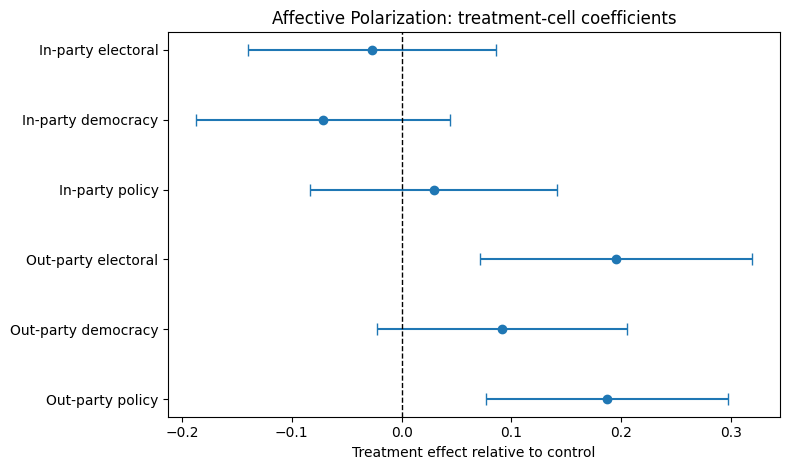

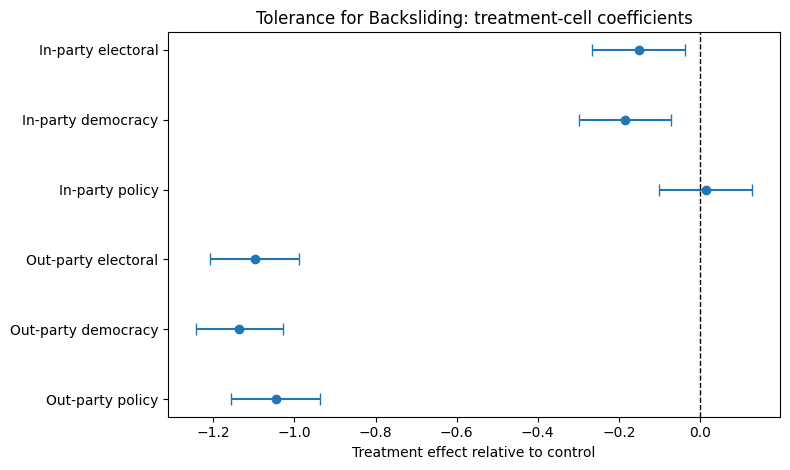

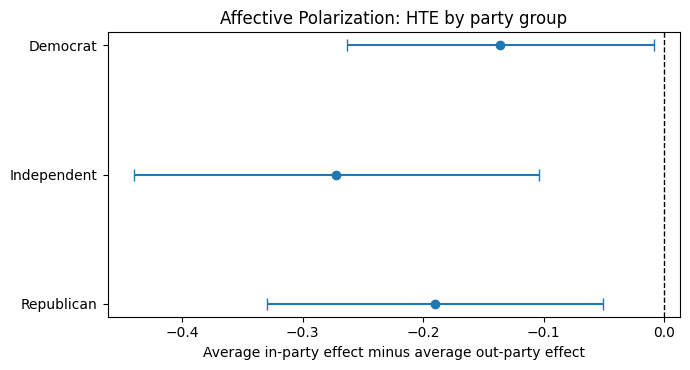

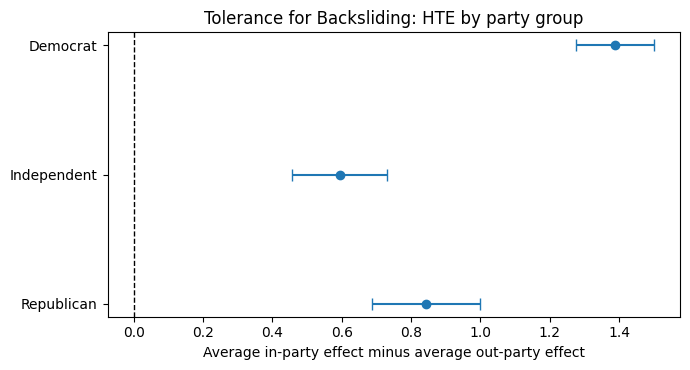

In [10]:
  #coefficient plots

  results.graph_delta_ap()
  print("\n")
  results.graph_delta_tb()
  print("\n")
  results.plot_hte_in_vs_out('AP')
  print("\n")
  results.plot_hte_in_vs_out('TB')
  print("\n")

In [11]:
#hte tests
results.print_hte_tests_all()


Party group: Democrat (n=1203)
Any treatment (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0333      0.065      0.513      0.608      -0.094       0.161
Any treatment (TB)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.5201      0.055     -9.446      0.000      -0.628      -0.412
In vs Out party (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.1359      0.065     -2.

### Pre-Treatment Descriptive Analyses
This section uses only pre-treatment variables. It evaluates pre-treatment affective polarization, pre-treatment tolerance for backsliding, and the `Q-DemThreat` selection of the most egregious democratic-backsliding action. The compact regressions use party-ID direction, party-ID strength, reduced education groups, reduced race groups, ordinal household income, and a Hispanic/Latino ethnicity indicator; treatment variables are not included.

In [12]:
from IPython.display import display

# --- Pre-treatment descriptive analysis setup ---

def _stars(pval):
  if pd.isna(pval):
    return ''
  if pval < 0.001:
    return '***'
  if pval < 0.01:
    return '**'
  if pval < 0.05:
    return '*'
  if pval < 0.10:
    return '+'
  return ''


def _clean_term_name(term):
  """Make statsmodels coefficient names readable in displayed tables."""
  replacements = {
      'Intercept': 'Intercept',
      'PID_direction': 'PID direction',
      'PID_strength': 'PID strength',
      'Income_num': 'Household income (ordinal)',
      'Hispanic': 'Hispanic/Latino ethnicity',
      'APpre': 'Pre-treatment AP',
      'TBpre': 'Pre-treatment tolerance',
      'N': 'N',
      'R-squared': 'R-squared',
  }
  if term in replacements:
    return replacements[term]

  edu_prefixes = [
      'Education_group[T.',
      'C(Education_group, Treatment(reference="College"))[T.',
  ]
  race_prefixes = [
      'Race_group[T.',
      'C(Race_group, Treatment(reference="White"))[T.',
  ]
  for edu_prefix in edu_prefixes:
    if term.startswith(edu_prefix):
      return 'Education: ' + term.replace(edu_prefix, '').rstrip(']')
  for race_prefix in race_prefixes:
    if term.startswith(race_prefix):
      return 'Race: ' + term.replace(race_prefix, '').rstrip(']')
  return term


def regression_table(models, decimals=3):
  """
  Compact regression table with coefficient stars and robust standard errors.
  Models should already be fit with the desired covariance estimator.
  """
  terms = []
  for model in models.values():
    for term in model.params.index:
      if term not in terms:
        terms.append(term)

  rows = []
  for term in terms:
    row = {'term': _clean_term_name(term)}
    for label, model in models.items():
      if term in model.params.index:
        coef = model.params[term]
        se = model.bse[term]
        pval = model.pvalues[term]
        row[label] = f'{coef:.{decimals}f}{_stars(pval)} ({se:.{decimals}f})'
      else:
        row[label] = ''
    rows.append(row)

  for stat_name, attr in [('N', 'nobs'), ('R-squared', 'rsquared')]:
    row = {'term': stat_name}
    for label, model in models.items():
      value = getattr(model, attr)
      row[label] = f'{int(value)}' if stat_name == 'N' else f'{value:.{decimals}f}'
    rows.append(row)

  return pd.DataFrame(rows).set_index('term')


def recode_education(value):
  if pd.isna(value) or value == 'Prefer not to say':
    return np.nan
  if value in [
      'Less than a high school diploma',
      'High school graduate - high school diploma or the equivalent (for example: GED)',
  ]:
    return 'High school or less'
  if value in [
      'Some college, but no degree',
      "Associate's degree (for example: AA, AS)",
      "Bachelor's degree (for example: BA, AB, BS)",
  ]:
    return 'College'
  if value in [
      "Master's degree (for example: MA, MS, MEng, MEd, MSW, MBA)",
      'Professional degree (for example: MD, DDS, DVM, LLB, JD)',
      'Doctorate degree (for example: PhD, EdD)',
  ]:
    return 'Postgraduate'
  return np.nan


def recode_race(value):
  if pd.isna(value) or value == 'Prefer not to say':
    return np.nan
  if value in ['Vietnamese', 'Filipino', 'Asian Indian', 'Chinese', 'Korean', 'Japanese']:
    return 'Asian'
  if value in [
      'American Indian or Alaska Native',
      'Native Hawaiian or Pacific Islander',
      'Hawaiian',
      'Guamanian',
  ]:
    return 'Native American'
  if value == 'An ethnicity not listed here':
    return 'Other'
  if value in ['White', 'Black or African American', 'Other']:
    return 'Black' if value == 'Black or African American' else value
  return value


income_map = {
    'Less than $10,000': 1,
    '$10,000-$19,999': 2,
    '$20,000-$29,999': 3,
    '$30,000-$39,999': 4,
    '$40,000-$49,999': 5,
    '$50,000-$59,999': 6,
    '$60,000-$69,999': 7,
    '$70,000-$79,999': 8,
    '$80,000-$89,999': 9,
    '$90,000-$99,999': 10,
    '$100,000-$124,999': 11,
    '$125,000-$149,999': 12,
    '$150,000-$174,999': 13,
    '$175,000-$199,999': 14,
    '$200,000-$224,999': 15,
    '$225,000-$249,999': 16,
    '$250,000 or more': 17,
}


def recode_hispanic(value):
  if pd.isna(value) or value == 'Prefer not to say':
    return np.nan
  return int(str(value).startswith('Yes'))


def get_pretreatment_data():
  """Build the pre-treatment analysis dataset without using post-treatment outcomes."""
  base = results.df.copy() if 'results' in globals() else df.copy()
  if 'Treat_Party' in base.columns:
    base = base[~base['Treat_Party'].str.contains('ImportId', na=False)].copy()

  base['Feeling_ThermR'] = pd.to_numeric(base['Q-FeelingTherm_1'], errors='coerce')
  base['Feeling_ThermD'] = pd.to_numeric(base['Q-FeelingTherm_2'], errors='coerce')
  base['APpre'] = (base['Feeling_ThermR'] - base['Feeling_ThermD']).abs()
  base['TBpre'] = base['Q-AffPolarization'].map(tolerance_map)
  base['PA'] = base.apply(seven_pt_pid, axis=1)
  base['PartyGroup'] = base.apply(get_party_group, axis=1)
  base['DemThreat'] = base['Q-DemThreat'].replace('', np.nan)

  pa_labels = {
      1: '1 Strong Democrat',
      2: '2 Weak Democrat',
      3: '3 Dem-leaning Independent',
      4: '4 Pure Independent',
      5: '5 Rep-leaning Independent',
      6: '6 Weak Republican',
      7: '7 Strong Republican',
  }
  base['PA_label'] = base['PA'].map(pa_labels)

  # Split seven-point party ID into direction and strength.
  # PID_direction: higher values move from Democratic toward Republican ID.
  # PID_strength: distance from pure Independent, regardless of party side.
  base['PID_direction'] = base['PA'] - 4
  base['PID_strength'] = (base['PA'] - 4).abs()

  base['Education_group'] = pd.Categorical(
      base['Education'].apply(recode_education),
      categories=['College', 'High school or less', 'Postgraduate'],
      ordered=False,
  )
  base['Race_group'] = pd.Categorical(
      base['Race'].apply(recode_race),
      categories=['White', 'Black', 'Asian', 'Native American', 'Other'],
      ordered=False,
  )
  base['Income_num'] = base['Household Income'].map(income_map)
  base['Hispanic'] = base['Ethnicity'].apply(recode_hispanic)
  return base


pre_data = get_pretreatment_data()
demographic_terms = [
    'Education_group',
    'Race_group',
    'Income_num',
    'Hispanic',
]
demographic_controls_used = [
    'Education_group',
    'Race_group',
    'Income_num',
    'Hispanic',
]
print('Demographic controls used:', ', '.join(demographic_controls_used))


Demographic controls used: Education_group, Race_group, Income_num, Hispanic


In [13]:
# Summary table: pre-treatment AP and tolerance by seven-point party ID.
pid_pretreatment_table = (
    pre_data
    .dropna(subset=['PA'])
    .groupby(['PA', 'PA_label'], observed=True)
    .agg(
        n=('PA', 'size'),
        APpre_mean=('APpre', 'mean'),
        APpre_sd=('APpre', 'std'),
        TBpre_mean=('TBpre', 'mean'),
        TBpre_sd=('TBpre', 'std'),
    )
    .reset_index()
    .sort_values('PA')
)

display(pid_pretreatment_table[['PA_label', 'n', 'APpre_mean', 'APpre_sd', 'TBpre_mean', 'TBpre_sd']].round(3))

pretreatment_formula_rhs = 'PID_direction + PID_strength' + (' + ' + ' + '.join(demographic_terms) if demographic_terms else '')
pre_ap_model = run_ols(f'APpre ~ {pretreatment_formula_rhs}', pre_data)
pre_tb_model = run_ols(f'TBpre ~ {pretreatment_formula_rhs}', pre_data)

pretreatment_regression_models = {
    'Pre-treatment AP': pre_ap_model,
    'Pre-treatment tolerance': pre_tb_model,
}
pretreatment_regression_table = regression_table(pretreatment_regression_models)
display(pretreatment_regression_table)


,PA_label,n,APpre_mean,APpre_sd,TBpre_mean,TBpre_sd
0,1 Strong Democrat,739,63.862,23.790,1.805,1.151
1,2 Weak Democrat,467,40.313,24.882,1.931,1.123
2,3 Dem-leaning Independent,328,36.899,25.368,1.863,1.200
3,4 Pure Independent,282,11.075,16.907,2.060,1.312
4,5 Rep-leaning Independent,147,24.850,25.152,2.034,1.367
5,6 Weak Republican,340,30.315,25.754,2.035,1.202
6,7 Strong Republican,342,53.416,27.930,2.094,1.194


,Pre-treatment AP,Pre-treatment tolerance
term,,
Intercept,12.791*** (1.584),1.890*** (0.080)
Education: High school or less,0.081 (1.633),0.184* (0.083)
Education: Postgraduate,-0.934 (1.397),-0.040 (0.067)
Race: Black,-4.871** (1.682),0.220** (0.078)
Race: Asian,-5.678** (2.168),0.259* (0.107)
Race: Native American,-1.206 (5.281),-0.071 (0.214)
Race: Other,-4.725 (2.882),0.195 (0.142)
PID direction,-2.384*** (0.266),0.048*** (0.012)
PID strength,14.802*** (0.500),0.021 (0.026)


### Most Egregious Backsliding Action
The bar chart describes which `Q-DemThreat` action respondents selected as most egregious. The table below it fits five separate binary OLS models, one for each action being selected, using pre-treatment AP, pre-treatment tolerance, party-ID direction, party-ID strength, and the compact demographic controls.

,action,n,share
0,Restructuring the state’s highest court to fav...,1021,0.375
1,Manipulating geographic boundaries of election...,866,0.318
2,Prosecuting journalists for unfair news coverage,339,0.124
3,Directing law enforcement to investigate polit...,289,0.106
4,Banning political rallies,210,0.077


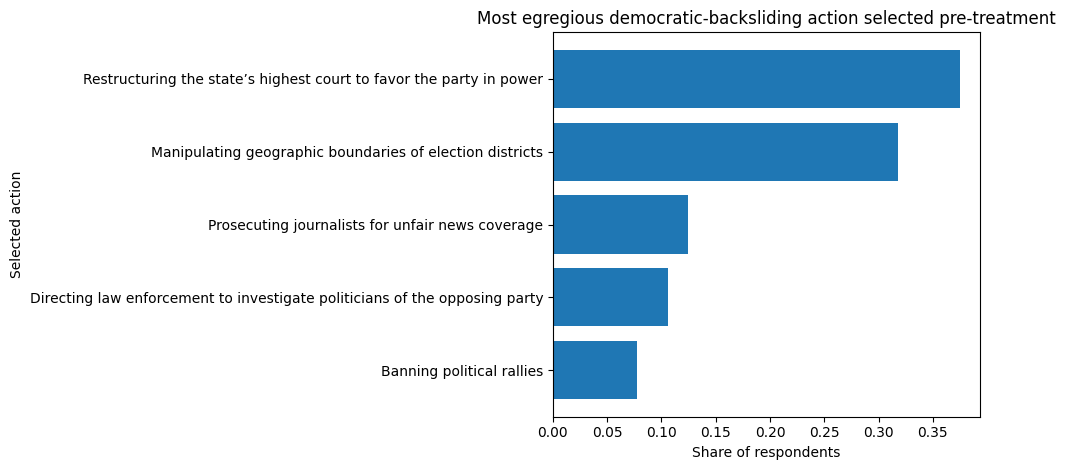

In [14]:
# Distribution of the selected most egregious democratic-backsliding action.
dem_threat_counts = pre_data['DemThreat'].value_counts(dropna=True)
dem_threat_distribution = (
    dem_threat_counts
    .rename_axis('action')
    .reset_index(name='n')
)
dem_threat_distribution['share'] = dem_threat_distribution['n'] / dem_threat_distribution['n'].sum()

display(dem_threat_distribution.assign(share=lambda x: x['share'].round(3)))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(dem_threat_distribution['action'], dem_threat_distribution['share'])
ax.set_xlabel('Share of respondents')
ax.set_ylabel('Selected action')
ax.set_title('Most egregious democratic-backsliding action selected pre-treatment')
ax.invert_yaxis()
fig.tight_layout()
plt.show()


In [15]:
# Summary table: pre-treatment AP and tolerance by selected Q-DemThreat action.
action_pretreatment_table = (
    pre_data
    .dropna(subset=['DemThreat'])
    .groupby('DemThreat', observed=True)
    .agg(
        n=('DemThreat', 'size'),
        APpre_mean=('APpre', 'mean'),
        APpre_sd=('APpre', 'std'),
        TBpre_mean=('TBpre', 'mean'),
        TBpre_sd=('TBpre', 'std'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
)

display(action_pretreatment_table.round(3))

# Five-column action-selection regression table: one linear probability model per action.
action_regression_data = pre_data.dropna(subset=['DemThreat']).copy()
action_rhs = 'APpre + TBpre + PID_direction + PID_strength' + (' + ' + ' + '.join(demographic_terms) if demographic_terms else '')
action_models = {}
for i, action in enumerate(dem_threat_distribution['action'], start=1):
  dep = f'DemThreat_action_{i}'
  action_regression_data[dep] = (action_regression_data['DemThreat'] == action).astype(int)
  short_label = action.split(' to ')[0]
  if len(short_label) > 38:
    short_label = short_label[:35] + '...'
  action_models[short_label] = run_ols(f'{dep} ~ {action_rhs}', action_regression_data)

action_selection_regression_table = regression_table(action_models)
display(action_selection_regression_table)


,DemThreat,n,APpre_mean,APpre_sd,TBpre_mean,TBpre_sd
4,Restructuring the state’s highest court to fav...,1021,40.595,29.153,1.929,1.160
2,Manipulating geographic boundaries of election...,866,46.259,30.464,1.931,1.220
3,Prosecuting journalists for unfair news coverage,339,38.024,28.697,1.973,1.293
1,Directing law enforcement to investigate polit...,289,42.920,29.495,1.965,1.148
0,Banning political rallies,210,37.910,31.999,2.219,1.383


,Restructuring the state’s highest c...,Manipulating geographic boundaries ...,Prosecuting journalists for unfair ...,Directing law enforcement,Banning political rallies
term,,,,,
Intercept,0.424*** (0.037),0.311*** (0.036),0.147*** (0.026),0.065** (0.023),0.052* (0.022)
Education: High school or less,0.017 (0.031),0.005 (0.030),-0.021 (0.020),-0.021 (0.018),0.021 (0.018)
Education: Postgraduate,-0.025 (0.027),-0.014 (0.026),0.000 (0.020),0.014 (0.018),0.024 (0.016)
Race: Black,0.016 (0.033),0.078* (0.033),-0.065*** (0.019),-0.019 (0.019),-0.009 (0.016)
Race: Asian,0.074+ (0.045),-0.062 (0.040),0.015 (0.033),0.006 (0.029),-0.034+ (0.018)
Race: Native American,0.039 (0.094),-0.153* (0.078),0.004 (0.067),0.041 (0.067),0.069 (0.067)
Race: Other,0.071 (0.061),0.062 (0.059),-0.048 (0.037),-0.067** (0.024),-0.017 (0.031)
Pre-treatment AP,-0.001 (0.000),0.002*** (0.000),-0.001*** (0.000),0.000 (0.000),-0.000 (0.000)
Pre-treatment tolerance,-0.010 (0.009),-0.002 (0.009),0.002 (0.007),-0.000 (0.005),0.010+ (0.005)
